<a href="https://colab.research.google.com/github/gisele-mgs/especializacacin/blob/main/Exerc%C3%ADcio_Grafos_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gravis
!pip install plotly_express

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 659.1/659.1 kB 10.5 MB/s eta 0:00:00


In [ ]:
import networkx as nx
import pandas as pd
import gravis as gv
import plotly_express as px

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Este exercício se baseia em dados sobre as personagens de Game of Thrones (arquivo *asoiaf.csv*). Se você nunca ouviu falar de Game of Thrones, então você deve ser muito bom em viver no mundo offline. Game of Thrones é uma série de televisão extremamente popular da HBO, baseada na (também) extremamente popular série de livros "As Crónicas de Gelo e Fogo" de George R.R. Martin. Vamos analisar o grafo de coocorrência das personagens dos livros. Neste caso, considera-se que duas personagens são co-ocorrentes se os seus nomes aparecerem no máximo em 15 palavras de distância nos livros. Para cada par de personagens, o número de vezes que esse fato ocorre é codificado no atributo *weight*.

0) Carregue o arquivo

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/asoiaf.csv")
df

,id,Source,Target,Type,weight,book,weight_inv
0,0,Addam-Marbrand,Jaime-Lannister,Undirected,3,1.0,0.333333
1,1,Addam-Marbrand,Tywin-Lannister,Undirected,6,1.0,0.166667
2,2,Aegon-I-Targaryen,Daenerys-Targaryen,Undirected,5,1.0,0.200000
3,3,Aegon-I-Targaryen,Eddard-Stark,Undirected,4,1.0,0.250000
4,4,Aemon-Targaryen-(Maester-Aemon),Alliser-Thorne,Undirected,4,1.0,0.250000
...,...,...,...,...,...,...,...
3904,3904,Tyrion-Lannister,Ysilla,undirected,11,5.0,0.090909
3905,3905,Tywin-Lannister,Wylis-Manderly,undirected,3,5.0,0.333333
3906,3906,Victarion-Greyjoy,Wulfe,undirected,3,5.0,0.333333
3907,3907,Walder-Frey-(son-of-Jammos),Walder-Frey-(son-of-Merrett),undirected,10,5.0,0.100000


1) Use a função [from_pandas_edgelist](https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_pandas_edgelist.html) da biblioteca networkX para converter a informação no dataframe carregado acima para ter uma lista de grafos chamadas *graphs*, um para cada um dos livros.

In [ ]:
G = nx.from_pandas_edgelist(df[df.book == 1],source="Source",target="Target",edge_attr="weight")

2) Plote o grafo correspondente ao primeiro livro usando um diagrama de nós e arestas. Use o atributo *weight* como sendo a largura da aresta.

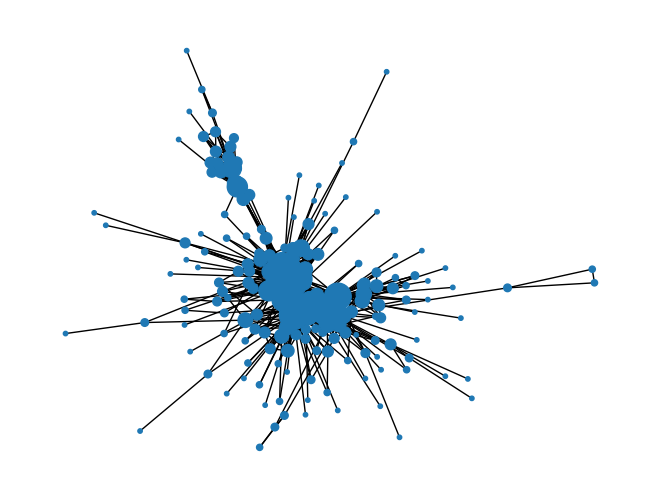

In [ ]:
weights = [G.edges[t]['weight']  for t in G.edges]
degrees = [10*val for (node, val) in G.degree()]
positions = nx.spring_layout(G)

nx.draw(G,positions,node_size=degrees)

In [ ]:
print(G.nodes)
print(G.edges)


gv.d3(G, layout_algorithm_active=True)

['Aegon-I-Targaryen', 'Daenerys-Targaryen', 'Aegon-Targaryen-(son-of-Rhaegar)', 'Elia-Martell', 'Franklyn-Flowers', 'Haldon', 'Harry-Strickland', 'Jon-Connington', 'Lemore', 'Rhaegar-Targaryen', 'Rhaenys-Targaryen-(daughter-of-Rhaegar)', 'Rolly-Duckfield', 'Tyrion-Lannister', 'Tywin-Lannister', 'Viserys-Targaryen', 'Yandry', 'Ysilla', 'Aemon-Targaryen-(Maester-Aemon)', 'Clydas', 'Gilly', 'Jon-Snow', 'Samwell-Tarly', 'Stannis-Baratheon', 'Aenys-Frey', 'Hosteen-Frey', 'Theon-Greyjoy', 'Wyman-Manderly', 'Aeron-Greyjoy', 'Euron-Greyjoy', 'Victarion-Greyjoy', 'Aerys-II-Targaryen', 'Robert-Baratheon', 'Aggo', 'Barristan-Selmy', 'Daario-Naharis', 'Grey-Worm', 'Jhogo', 'Rakharo', 'Alliser-Thorne', 'Alys-Karstark', 'Melisandre', 'Sigorn', 'Alysane-Mormont', 'Asha-Greyjoy', 'Justin-Massey', 'Archibald-Yronwood', 'Cletus-Yronwood', 'Gerris-Drinkwater', 'Quentyn-Martell', 'Tattered-Prince', 'Areo-Hotah', 'Arianne-Martell', 'Arys-Oakheart', 'Balon-Swann', 'Doran-Martell', 'Ellaria-Sand', 'Obara-San

3) Ao analisar redes sociais (como estas de Game of Thrones) uma das noções importantes é investigar a importância de um determinado vértice. Em geral, essas medidas são chamadas centralidade. Existem várias
possíveis noções de centralidade. Uma delas é a centralidade de grau (degree centrality) que é uma medida numérica que indica a porcentagem do total das conexões que um nó realmente tem. Use a função [nx.degree_centrality](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.degree_centrality.html) para calcular essa medida para os nós de cada um dos grafos dos livros. Use também a função [nx.set_node_attributes](https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.set_node_attributes.html) para adicionar essa informação ao grafo.

In [ ]:
G.degree()

DegreeView({'Addam-Marbrand': 2, 'Jaime-Lannister': 29, 'Tywin-Lannister': 22, 'Aegon-I-Targaryen': 2, 'Daenerys-Targaryen': 21, 'Eddard-Stark': 66, 'Aemon-Targaryen-(Maester-Aemon)': 7, 'Alliser-Thorne': 10, 'Bowen-Marsh': 5, 'Chett': 3, 'Clydas': 1, 'Jeor-Mormont': 13, 'Jon-Snow': 37, 'Samwell-Tarly': 12, 'Aerys-II-Targaryen': 6, 'Brandon-Stark': 6, 'Gerold-Hightower': 5, 'Jon-Arryn': 15, 'Robert-Baratheon': 50, 'Aggo': 6, 'Drogo': 19, 'Jhogo': 6, 'Jorah-Mormont': 13, 'Quaro': 5, 'Rakharo': 5, 'Albett': 3, 'Halder': 8, 'Rast': 6, 'Grenn': 7, 'Pypar': 7, 'Tyrion-Lannister': 46, 'Alyn': 5, 'Harwin': 4, 'Jory-Cassel': 21, 'Tomard': 7, 'Arthur-Dayne': 1, 'Arya-Stark': 27, 'Benjen-Stark': 14, 'Bran-Stark': 32, 'Catelyn-Stark': 43, 'Cersei-Lannister': 30, 'Desmond': 2, 'Ilyn-Payne': 9, 'Jeyne-Poole': 6, 'Joffrey-Baratheon': 30, 'Meryn-Trant': 9, 'Mordane': 11, 'Mycah': 5, 'Myrcella-Baratheon': 7, 'Petyr-Baelish': 26, 'Rickon-Stark': 9, 'Robb-Stark': 35, 'Rodrik-Cassel': 18, 'Sandor-Clegane

In [ ]:
centro = nx.degree_centrality(G)
degre = dict(G.degree())
nx.set_node_attributes(G,centro,'degree_centrality')

In [ ]:
gv.vis(G, use_node_size_normalization=True, node_size_normalization_max=30,
      use_edge_size_normalization=True, edge_size_data_source='weight')

# 4) Faça gráficos da distribuição das medidas de centralidade acima para cada um dos livros. O que você consegue observar nestes gráficos?

1. Devido a grande quantidade de personagens presentes nas Crônicas de Gelo e Fogo, existe uma dificuldade de visualizar a frequência de cada personagem.

livro 1:

Personagens relevantes: Eddard-Stark, Robert Baratheon.
A trama gira em torno das famílias desses dois, assim, envolvendo também os agregados das famílias.

Dessa forma, pode-se identificar Sansa, Catelyn, Jon Snow, Jaime-Lannister, Tyron Lannister e Cersei Lannister

Nos demais, por ser um livro introdutório da saga, aparecem de maneira mais dispersa

In [ ]:
import plotly_express as px
import random

myNodes = list(G.nodes())
random.shuffle(myNodes)
A = nx.adjacency_matrix(G,nodelist=myNodes,weight=None)
#print(A)
AA = A.todense()
#print(AA)

fig = px.imshow(AA,x=myNodes,y=myNodes,width=1000,height=1000)
fig.update_traces(dict(showscale=False,
                       coloraxis=None,
                       colorscale='purples'), selector={'type':'heatmap'})
fig.show()

livro 2:

Nesse livro, fica um pouco mais difícil identificar os personagens principais. É possível notar um arco entre Tyron Lannister, Cersei Lannister, Joffrey Lannister, Arya

In [ ]:
G2 = nx.from_pandas_edgelist(df[df.book == 2],source="Source",target="Target",edge_attr="weight")

centro2 = nx.degree_centrality(G2)
degre2 = dict(G2.degree())
nx.set_node_attributes(G2,centro2,'degree_centrality')

myNodes = list(G2.nodes())
random.shuffle(myNodes)
A = nx.adjacency_matrix(G2,nodelist=myNodes,weight=None)
#print(A)
AA = A.todense()
fig = px.imshow(AA,x=myNodes,y=myNodes,width=1000,height=1000)
fig.update_traces(dict(showscale=False,
                       coloraxis=None,
                       colorscale='purples'), selector={'type':'heatmap'})
fig.show()


livro 3:

Arco entre Robb-Stark, Sansa Stark,, Jon Snow, Joffrey Lannister, Cersei Lannister, Tyron Lannister e Jaime Lannister

In [ ]:
G3 = nx.from_pandas_edgelist(df[df.book == 3],source="Source",target="Target",edge_attr="weight")

centro3 = nx.degree_centrality(G3)
degre3 = dict(G3.degree())
nx.set_node_attributes(G3,centro3,'degree_centrality')

myNodes = list(G3.nodes())
random.shuffle(myNodes)
A = nx.adjacency_matrix(G3,nodelist=myNodes,weight=None)
#print(A)
AA = A.todense()
fig = px.imshow(AA,x=myNodes,y=myNodes,width=1000,height=1000)
fig.update_traces(dict(showscale=False,
                       coloraxis=None,
                       colorscale='purples'), selector={'type':'heatmap'})
fig.show()


Livro 4:

Cersei e Jaime Lannister com maior frequência

In [ ]:
G4 = nx.from_pandas_edgelist(df[df.book == 4],source="Source",target="Target",edge_attr="weight")

centro4 = nx.degree_centrality(G4)
degre4 = dict(G4.degree())
nx.set_node_attributes(G4,centro4,'degree_centrality')

myNodes = list(G4.nodes())
random.shuffle(myNodes)
A = nx.adjacency_matrix(G4,nodelist=myNodes,weight=None)
#print(A)
AA = A.todense()
fig = px.imshow(AA,x=myNodes,y=myNodes,width=1000,height=1000)
fig.update_traces(dict(showscale=False,
                       coloraxis=None,
                       colorscale='purples'), selector={'type':'heatmap'})
fig.show()


Livro 5:

In [ ]:
G5 = nx.from_pandas_edgelist(df[df.book == 5],source="Source",target="Target",edge_attr="weight")

centro5 = nx.degree_centrality(G5)
degre5 = dict(G5.degree())
nx.set_node_attributes(G5,centro5,'degree_centrality')

myNodes = list(G5.nodes())
random.shuffle(myNodes)
A = nx.adjacency_matrix(G5,nodelist=myNodes,weight=None)
#print(A)
AA = A.todense()
fig = px.imshow(AA,x=myNodes,y=myNodes,width=1000,height=1000)
fig.update_traces(dict(showscale=False,
                       coloraxis=None,
                       colorscale='purples'), selector={'type':'heatmap'})
fig.show()




# 5) Ache os 5 personagems mais centrais para o primeiro e para o último livro. Estes resultados batem com seu conhecimento da série?


Sim, os resultados são coerentes com os conhecimentos da série.

Livro 1:
1.  Jon-Snow: 0.196
2. Daenerys-Targaryen: 0.184
3. Stannis-Baratheon: 0.149
4. Tyrion-Lannister: 0.104
5. Theon-Greyjoy: 0.104

In [ ]:
deg_cent_G = nx.degree_centrality(G)
top5_G = sorted(deg_cent_G.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 personagens mais centrais no Livro 1:")
for char, cent in top5_G:
    print(f"{char}: {cent:.3f}")


Top 5 personagens mais centrais no Livro 1:
Jon-Snow: 0.196
Daenerys-Targaryen: 0.184
Stannis-Baratheon: 0.149
Tyrion-Lannister: 0.104
Theon-Greyjoy: 0.104


Livro 5:

1. Jon-Snow: 0.196
2. Daenerys-Targaryen: 0.184
3. Stannis-Baratheon: 0.149
4. Tyrion-Lannister: 0.104
5. Theon-Greyjoy: 0.104

In [ ]:
deg_cent_G5 = nx.degree_centrality(G5)
top5_G5 = sorted(deg_cent_G5.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 personagens mais centrais no Livro 5:")
for char, cent in top5_G5:
    print(f"{char}: {cent:.3f}")


Top 5 personagens mais centrais no Livro 5:
Jon-Snow: 0.196
Daenerys-Targaryen: 0.184
Stannis-Baratheon: 0.149
Tyrion-Lannister: 0.104
Theon-Greyjoy: 0.104


# 6) Agora vamos estudar a evolução da importância dos personagens ao longo dos livros. Construa um gráfico para visualizar este fato para os seguintes personagens:

'Arya-Stark',
 'Brienne-of-Tarth',
 'Catelyn-Stark',
 'Cersei-Lannister',
 'Daenerys-Targaryen',
 'Eddard-Stark',
 'Jaime-Lannister',
 'Joffrey-Baratheon',
 'Jon-Snow',
 'Margaery-Tyrell',
 'Robb-Stark',
 'Robert-Baratheon',
 'Sansa-Stark',
 'Stannis-Baratheon',
 'Theon-Greyjoy',
 'Tyrion-Lannister'. Você consegue observar padrões interessantes nestas evoluções?

1. Eddard Stark:

- Domina o Livro 1 (AGOT) com a centralidade mais alta

- Desaparece completamente após o Livro 1


2. Tyrion Lannister:

- Mantém alta centralidade em todos os livros


3. Jon Snow e Daenerys Targaryen:

- Crescimento contínuo até o Livro 5 (ADWD)


4. Catelyn e Robb Stark:

- Pico no Livro 3 (ASOS)

- Queda abrupta no Livro 4 (corresponde ao evento da Red Wedding)

5. Cersei Lannister:

- Aumento gradual até o Livro 4 (AFFC)



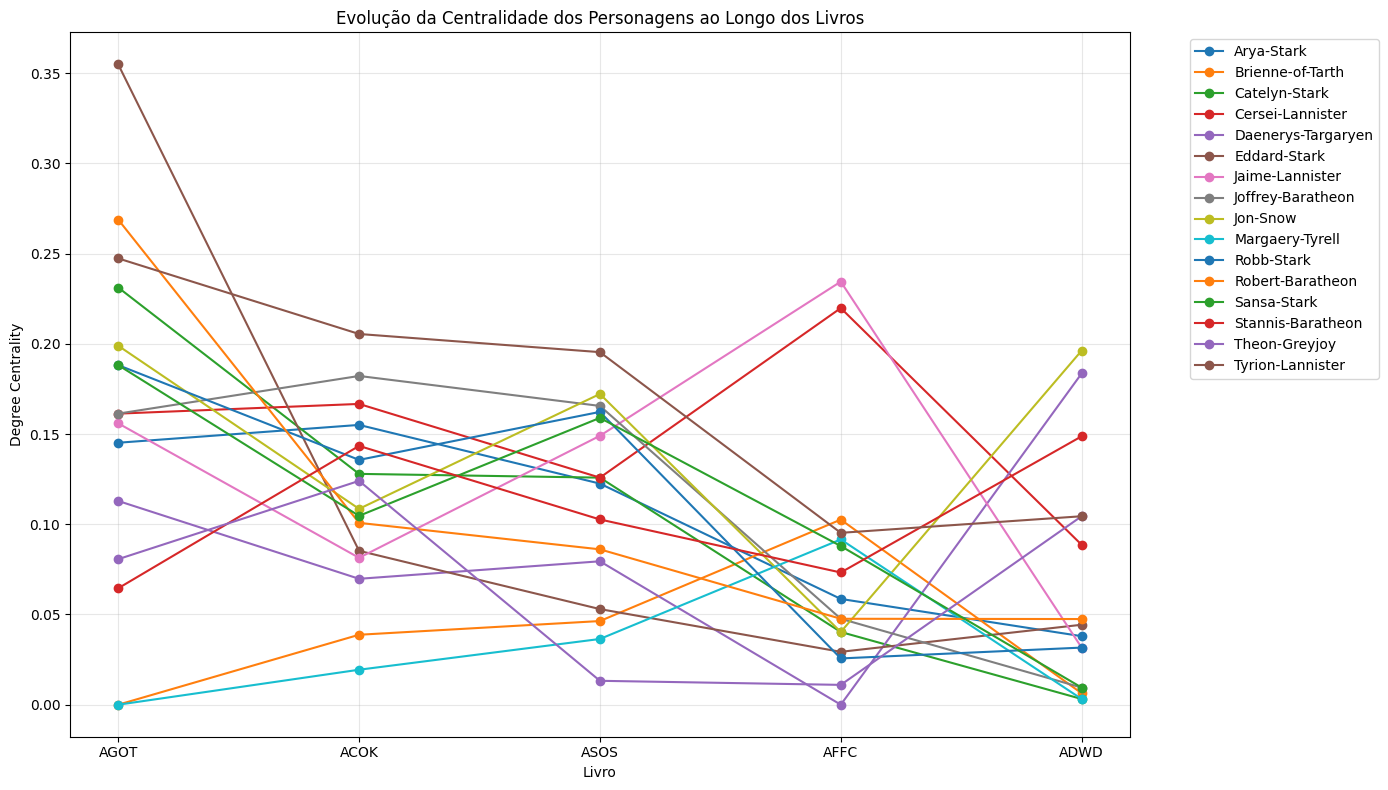

In [ ]:
import matplotlib.pyplot as plt

# Lista de personagens de interesse
characters = [
    'Arya-Stark', 'Brienne-of-Tarth', 'Catelyn-Stark', 'Cersei-Lannister',
    'Daenerys-Targaryen', 'Eddard-Stark', 'Jaime-Lannister', 'Joffrey-Baratheon',
    'Jon-Snow', 'Margaery-Tyrell', 'Robb-Stark', 'Robert-Baratheon',
    'Sansa-Stark', 'Stannis-Baratheon', 'Theon-Greyjoy', 'Tyrion-Lannister'
]


books = [1, 2, 3, 4, 5]
centrality_evolution = {char: [] for char in characters}

for book in books:
    G = nx.from_pandas_edgelist(df[df.book == book], source="Source", target="Target", edge_attr="weight")
    deg_cent = nx.degree_centrality(G)

    for char in characters:
        centrality_evolution[char].append(deg_cent.get(char, 0))


plt.figure(figsize=(14, 8))

for char in characters:
    plt.plot(books, centrality_evolution[char], 'o-', label=char)

plt.title('Evolução da Centralidade dos Personagens ao Longo dos Livros')
plt.xlabel('Livro')
plt.ylabel('Degree Centrality')
plt.xticks(books, ['AGOT', 'ACOK', 'ASOS', 'AFFC', 'ADWD'])
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

7) Dizemos que uma rede tem uma estrutura comunitária se os nós da rede puderem ser facilmente agrupados em conjuntos de nós (potencialmente com sobreposição), de modo a que cada conjunto de nós esteja densamente ligado internamente. Existem vários algoritmos e definições para calcular estas comunidades numa rede.

Vamos usar o algoritmo de deteção de [comunidades de Louvain](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html) para encontrar comunidades nos grafos do primeiro e do último livro.

# Livro 1:

In [ ]:
louvain_communities1 = nx.algorithms.community.louvain_communities(G)
nodes_louvain_ordered = []
for comm in louvain_communities1:
  for node in comm:
    nodes_louvain_ordered.append(node)

#
A = nx.adjacency_matrix(G,nodelist=nodes_louvain_ordered,weight=None)
AA = A.todense()

fig = px.imshow(AA,x=nodes_louvain_ordered,y=nodes_louvain_ordered,width=1500,height=1500)
fig.update_traces(dict(showscale=False,
                       coloraxis=None,
                       colorscale='purples'), selector={'type':'heatmap'})
fig.show()

# Livro 5:

In [ ]:
louvain_communities = nx.algorithms.community.louvain_communities(G5)
nodes_louvain_ordered = []
for comm in louvain_communities:
  for node in comm:
    nodes_louvain_ordered.append(node)

#
A = nx.adjacency_matrix(G5,nodelist=nodes_louvain_ordered,weight=None)
AA = A.todense()

fig = px.imshow(AA,x=nodes_louvain_ordered,y=nodes_louvain_ordered,width=1500,height=1500)
fig.update_traces(dict(showscale=False,
                       coloraxis=None,
                       colorscale='purples'), selector={'type':'heatmap'})
fig.show()

8) Para o primeiro e último livros, plote a matriz de adjacências  correspondente, reordenando os vértices de acordo com as comunidades encontradas no item anterior.

In [ ]:
louvain_communities = nx.community.louvain_communities(G, resolution=1.0)

nodes_ordered = []
boundaries = [0]

for comm in louvain_communities:
    nodes_ordered.extend(list(comm))
    boundaries.append(boundaries[-1] + len(comm))

# Remover o primeiro 0 e converter para posições entre nós

boundary_positions = [b - 0.5 for b in boundaries[1:-1]]


A = nx.adjacency_matrix(G, nodelist=nodes_ordered, weight=None)
AA = A.todense()

fig = px.imshow(
    AA,
    x=nodes_ordered,
    y=nodes_ordered,
    width=1200,
    height=1200,
    color_continuous_scale='purples'
)

fig.update_traces(dict(showscale=False,
                       coloraxis=None,
                       colorscale='purples'), selector={'type':'heatmap'})


fig.update_layout(
    title="Matriz de Adjacência Ordenada por Comunidades",
    xaxis_title="Personagens",
    yaxis_title="Personagens",
    xaxis=dict(tickangle=-90, tickfont=dict(size=8)),
    yaxis=dict(tickfont=dict(size=8))
)

fig.show()

In [ ]:
print("\n=== Comunidades Detectadas ===")
for i, comm in enumerate(louvain_communities):
    print(f"\nComunidade {i + 1} ({len(comm)} personagens):")
    print(sorted(comm))  #


=== Comunidades Detectadas ===

Comunidade 1 (42 personagens):
['Aegon-Targaryen-(son-of-Rhaegar)', 'Aerys-II-Targaryen', 'Ashara-Dayne', 'Benerro', 'Black-Balaq', 'Elia-Martell', 'Franklyn-Flowers', 'Haldon', 'Harry-Strickland', 'Illyrio-Mopatis', 'Joffrey-Baratheon', 'Jon-Connington', 'Jorah-Mormont', 'Kasporio', 'Lemore', 'Lyanna-Stark', 'Malaquo-Maegyr', 'Morgo', 'Myles-Toyne', 'Nurse', 'Nyessos-Vhassar', 'Penny', 'Petyr-Baelish', 'Pono', 'Qavo-Nogarys', 'Rhaegar-Targaryen', 'Rhaenys-Targaryen-(daughter-of-Rhaegar)', 'Robert-Baratheon', 'Rolly-Duckfield', 'Scar', 'Shae', 'Shrouded-Lord', 'Sweets', 'Tybero-Istarion', 'Tyrion-Lannister', 'Tysha', 'Tywin-Lannister', 'Varys', 'Wylis-Manderly', 'Yandry', 'Yezzan-zo-Qaggaz', 'Ysilla']

Comunidade 2 (15 personagens):
['Alysane-Mormont', 'Asha-Greyjoy', 'Cromm', 'Galbart-Glover', 'Grimtongue', 'Hagen', 'Harl', 'Justin-Massey', 'Lorren', 'Qarl-the-Maid', 'Richard-Horpe', 'Rolfe-the-Dwarf', 'Sybelle-Glover', 'Torgon-Greyiron', 'Tristifer-Bo

In [ ]:

louvain_communities2 = nx.community.louvain_communities(G5, resolution=1.0)

nodes_ordered = []
boundaries = [0]

for comm in louvain_communities2:
    nodes_ordered.extend(list(comm))
    boundaries.append(boundaries[-1] + len(comm))

# Remover o primeiro 0 e converter para posições entre nós

boundary_positions = [b - 0.5 for b in boundaries[1:-1]]


A = nx.adjacency_matrix(G5, nodelist=nodes_ordered, weight=None)
AA = A.todense()

fig = px.imshow(
    AA,
    x=nodes_ordered,
    y=nodes_ordered,
    width=1200,
    height=1200,
    color_continuous_scale='purples'
)

fig.update_traces(dict(showscale=False,
                       coloraxis=None,
                       colorscale='purples'), selector={'type':'heatmap'})
fig.update_layout(
    title="Matriz de Adjacência Ordenada por Comunidades",
    xaxis_title="Personagens",
    yaxis_title="Personagens",
    xaxis=dict(tickangle=-90, tickfont=dict(size=8)),
    yaxis=dict(tickfont=dict(size=8))
)

fig.show()



In [ ]:
print("\n=== Comunidades Detectadas ===")
for i, comm in enumerate(louvain_communities):
    print(f"\nComunidade {i + 1} ({len(comm)} personagens):")
    print(sorted(comm))


=== Comunidades Detectadas ===

Comunidade 1 (61 personagens):
['Aegon-I-Targaryen', 'Aggo', 'Archibald-Yronwood', 'Barristan-Selmy', 'Barsena', 'Belaquo', 'Belwas', 'Ben-Plumm', 'Bloodbeard', 'Caggo', 'Camarron', 'Cleon', 'Cletus-Yronwood', 'Daario-Naharis', 'Daenerys-Targaryen', 'Daeron-II-Targaryen', 'Denzo-Dhan', 'Dick-Straw', 'Draqaz', 'Drogo', 'Eroeh', 'Ezzara', 'Galazza-Galare', 'Gerris-Drinkwater', 'Ghael', 'Goghor-the-Giant', 'Grazhar', 'Grey-Worm', 'Groleo', 'Hero', 'Hizdahr-zo-Loraq', 'Hugh-Hungerford', 'Irri', 'Jhiqui', 'Jhogo', 'Kedry', 'Khrazz', 'Larraq', 'Lucifer-Long', 'Lysono-Maar', 'Marghaz-zo-Loraq', 'Marselen', 'Meris', 'Mezzara', 'Miklaz', 'Missandei', 'Old-Bill-Bone', 'Qezza', 'Quaithe', 'Quentyn-Martell', 'Rakharo', 'Reznak-mo-Reznak', 'Skahaz-mo-Kandaq', 'Spotted-Cat', 'Steelskin', 'Symon-Stripeback', 'Tattered-Prince', 'Viserys-Targaryen', 'Widower', 'Xaro-Xhoan-Daxos', 'Yurkhaz-zo-Yunzak']

Comunidade 2 (42 personagens):
['Aegon-Targaryen-(son-of-Rhaegar)', '

9) Plote o diagrama de nós e arestas do primeiro e último livros. Use as centralidades como atributo de tamanho do nó, o atributo *weight* como sendo a largura da aresta e as comunidades para definir cores distintas para os nós. Para este fim, use como exemplo o código neste [link](https://robert-haas.github.io/gravis-docs/code/examples/basic_use.html). As comunidades detectadas fazem sentido no contexto da história?

In [ ]:

# Assignment of node sizes
nx.set_node_attributes(G, centro, 'size')

# Assignment of node colors
colors = ['red', 'blue', 'green', 'orange', 'pink']
for community, color in zip(louvain_communities1, colors):
    for node in community:
        G.nodes[node]['color'] = color

gv.d3(G, use_node_size_normalization=True, node_size_normalization_max=30,
      use_edge_size_normalization=True, edge_size_data_source='weight', edge_curvature=0.3)

In [ ]:

# Assignment of node sizes
nx.set_node_attributes(G, centro, 'size')

# Assignment of node colors
colors = ['red', 'blue', 'green', 'orange', 'pink']
for community, color in zip(louvain_communities1, colors):
    for node in community:
        G.nodes[node]['color'] = color

gv.d3(G, use_node_size_normalization=True, node_size_normalization_max=30,
      use_edge_size_normalization=True, edge_size_data_source='weight', edge_curvature=0.3)

In [ ]:


# Assignment of node sizes
nx.set_node_attributes(G5, centro5, 'size')

# Assignment of node colors
colors = ['red', 'blue', 'green', 'orange', 'pink']
for community, color in zip(louvain_communities2, colors):
    for node in community:
        G.nodes[node]['color'] = color

gv.d3(G, use_node_size_normalization=True, node_size_normalization_max=30,
      use_edge_size_normalization=True, edge_size_data_source='weight', edge_curvature=0.3)